In [2]:
import numpy as np
import xarray as xr
import glob
import netCDF4 as nc
import pandas as pd
# import xesmf as xe
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

## Functions

In [2]:
def fractional_year_to_datetime(fractional_years):
    '''Convert BerkeleyEarth fractional years into datetime.'''
    dates = []
    for year in fractional_years:
        year_int = int(year)
        day_of_year = int((year - year_int) * 365.25)
        date = pd.Timestamp(year=year_int, month=1, day=1) + pd.Timedelta(days=day_of_year)
        dates.append(date)
    return np.array(dates)


def weighted_spatial(data_array, lats):
    '''Take spatial average of annual/seasonal/monthly CMIP6 data.'''
    weights = np.cos(np.deg2rad(lats))
    if len(data_array.shape) == 3:
        weighted_data_array = np.multiply(data_array, weights[np.newaxis, :, np.newaxis])
        shape = np.shape(weighted_data_array)
        weighted_data_reshaped = np.reshape(weighted_data_array, (shape[0], shape[1]*shape[2]))
        weighted_sum = np.nansum(weighted_data_reshaped, 1)
    if len(data_array.shape) == 4:
        weighted_data_array = np.multiply(data_array, weights[np.newaxis, np.newaxis, :, np.newaxis])
        shape = np.shape(weighted_data_array)
        weighted_data_reshaped = np.reshape(weighted_data_array, (shape[0], shape[1], shape[2]*shape[3]))
        weighted_sum = np.nansum(weighted_data_reshaped, 2)
    if len(data_array.shape) == 5:
        weighted_data_array = np.multiply(data_array, weights[np.newaxis, np.newaxis, np.newaxis, :, np.newaxis])
        shape = np.shape(weighted_data_array)
        weighted_data_reshaped = np.reshape(weighted_data_array, (shape[0], shape[1], shape[2], shape[3]*shape[4]))
        weighted_sum = np.nansum(weighted_data_reshaped, 3)
    denom = np.nansum(weights)*144
    return np.divide(weighted_sum, denom)


def mod_saver_annual(type, region, model_name, M, P, periods, lats, lons, sat_and_slp, int_ext_sum):
    '''Save CMIP6 annual data.'''

    # create netcdf file
    path = '/glade/work/skygale/training-data/annual/'+type+'/'+region+'/'
    filename = path + model_name + '.nc'
    dataset = nc.Dataset(filename, 'w', format='NETCDF4')

    # define dimensions
    dataset.createDimension('member', M)
    dataset.createDimension('period', P)
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('sat_slp', 2)
    dataset.createDimension('i_e_sum', 3)

    # define variables
    var1 = dataset.createVariable('X_SAT_SLP', np.float32, ('member', 'period', 'lat', 'lon', 'sat_slp'))
    var1[:] = sat_and_slp

    var2 = dataset.createVariable('Y_I_E_SUM', np.float32, ('member', 'period', 'i_e_sum'))
    var2[:] = int_ext_sum
    dataset.close()

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    member_var = dataset.createVariable('member', 'f8', ('member',))
    member_var[:] = np.arange(1, M+1)

    period_var = dataset.createVariable('period', 'f8', ('period',))
    period_var[:] = periods

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    sat_slp_var = dataset.createVariable('sat_slp', 'f8', ('sat_slp',))
    sat_slp_var[:] = [1, 2]

    i_e_sum_var = dataset.createVariable('i_e_sum', 'f8', ('i_e_sum',))
    i_e_sum_var[:] = [1, 2, 3]

    dataset.close()


def mod_saver_seasonal(type, region, model_name, M, P, periods, lats, lons, sat_and_slp, int_ext_sum):
    '''Save CMIP6 seasonal data.'''

    # create netcdf file
    path = '/glade/work/skygale/training-data-slp/seasonal/'+type+'/'+region+'/'
    filename = path + model_name + '.nc'
    dataset = nc.Dataset(filename, 'w', format='NETCDF4')

    # define dimensions
    dataset.createDimension('member', M)
    dataset.createDimension('period', P)
    dataset.createDimension('season', 4)
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('sat_slp', 2)
    dataset.createDimension('i_e_sum', 3)

    # define variables
    var1 = dataset.createVariable('X_SAT_SLP', np.float32, ('member', 'period', 'season', 'lat', 'lon', 'sat_slp'))
    var1[:] = sat_and_slp

    var2 = dataset.createVariable('Y_I_E_SUM', np.float32, ('member', 'period', 'season', 'i_e_sum'))
    var2[:] = int_ext_sum
    dataset.close()

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    member_var = dataset.createVariable('member', 'f8', ('member',))
    member_var[:] = np.arange(1, M+1)

    period_var = dataset.createVariable('period', 'f8', ('period',))
    period_var[:] = periods

    season_var = dataset.createVariable('season', 'f8', ('season',))
    season_var[:] = np.arange(0, 4)

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    sat_slp_var = dataset.createVariable('sat_slp', 'f8', ('sat_slp',))
    sat_slp_var[:] = [1, 2]

    i_e_sum_var = dataset.createVariable('i_e_sum', 'f8', ('i_e_sum',))
    i_e_sum_var[:] = [1, 2, 3]

    dataset.close()


def mod_saver_monthly(type, region, model_name, M, P, periods, lats, lons, sat_and_slp, int_ext_sum):
    '''Save CMIP6 monthly data.'''

    # create netcdf file
    path = '/pscratch/sd/s/skygale/monthly-trends/'+type+'/'+region+'/'
    filename = path + model_name + '.nc'
    dataset = nc.Dataset(filename, 'w', format='NETCDF4')

    # define dimensions
    dataset.createDimension('member', M)
    dataset.createDimension('period', P)
    dataset.createDimension('month', 12)
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('sat_slp', 2)
    dataset.createDimension('i_e_sum', 3)

    # define variables
    var1 = dataset.createVariable('X_SAT_SLP', np.float32, ('member', 'period', 'month', 'lat', 'lon', 'sat_slp'))
    var1[:] = sat_and_slp

    var2 = dataset.createVariable('Y_I_E_SUM', np.float32, ('member', 'period', 'month', 'i_e_sum'))
    var2[:] = int_ext_sum
    dataset.close()

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    member_var = dataset.createVariable('member', 'f8', ('member',))
    member_var[:] = np.arange(1, M+1)

    period_var = dataset.createVariable('period', 'f8', ('period',))
    period_var[:] = periods

    month_var = dataset.createVariable('month', 'f8', ('month',))
    month_var[:] = np.arange(0, 12)

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    sat_slp_var = dataset.createVariable('sat_slp', 'f8', ('sat_slp',))
    sat_slp_var[:] = [1, 2]

    i_e_sum_var = dataset.createVariable('i_e_sum', 'f8', ('i_e_sum',))
    i_e_sum_var[:] = [1, 2, 3]

    dataset.close()


def obs_saver_annual(var, obs_name, data, lats, lons):
    '''Save observational annual data.'''

    # create netcdf file
    path = '/glade/work/skygale/training-data/annual/observations/'+var+'/'
    filename = path + obs_name + '.nc'
    dataset = nc.Dataset(filename, mode='w', format='NETCDF4')

    # define dimensions
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('data', 1)

    # define variables
    var = dataset.createVariable('DATA', np.float32, ('lat', 'lon'))
    var[:] = data

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    data_var = dataset.createVariable('data', 'f8', ('data',))
    data_var[:] = [1]

    dataset.close()


def obs_saver_seasonal(var, obs_name, data, lats, lons):
    '''Save observational seasonal data.'''

    # create netcdf file
    path = '/glade/work/skygale/training-data-slp/seasonal/observations/'+var+'/'
    filename = path + obs_name + '.nc'
    dataset = nc.Dataset(filename, mode='w', format='NETCDF4')

    # define dimensions
    # dataset.createDimension('season', 4)
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('data', 1)

    # define variables
    var = dataset.createVariable('DATA', np.float32, ('lat', 'lon'))
    var[:] = data

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    # season_var = dataset.createVariable('season', 'f8', ('season',))
    # season_var[:] = np.arange(0, 4)

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    data_var = dataset.createVariable('data', 'f8', ('data',))
    data_var[:] = [1]

    dataset.close()


def obs_saver_monthly(var, obs_name, data, lats, lons):
    '''Save observational monthly data.'''

    # create netcdf file
    path = '/pscratch/sd/s/skygale/monthly-trends/obs/'+var+'/'
    filename = path + obs_name + '.nc'
    dataset = nc.Dataset(filename, mode='w', format='NETCDF4')

    # define dimensions
    dataset.createDimension('month', 12)
    dataset.createDimension('lat', len(lats))
    dataset.createDimension('lon', len(lons))
    dataset.createDimension('data', 1)

    # define variables
    var = dataset.createVariable('DATA', np.float32, ('month', 'lat', 'lon'))
    var[:] = data

    # open NetCDF file in append mode
    dataset = nc.Dataset(filename, 'a')

    month_var = dataset.createVariable('month', 'f8', ('month',))
    month_var[:] = np.arange(0, 12)

    lat_var = dataset.createVariable('lat', 'f8', ('lat',))
    lat_var[:] = lats

    lon_var = dataset.createVariable('lon', 'f8', ('lon',))
    lon_var[:] = lons

    data_var = dataset.createVariable('data', 'f8', ('data',))
    data_var[:] = [1]

    dataset.close()

## Adjustments

In [3]:
# define processing type and region
type = 'hist'
region = 'arctic'

# paths to CMIP6 data
paths = glob.glob('/pscratch/sd/s/skygale/cmip6/monthly-processed/'+type+'/*')

if type == 'spliced':
    periods = np.arange(1855, 2010, 5)
if type == 'hist':
    periods = np.arange(1855, 1975, 5)

# script global variables
P = len(periods)
lats = np.arange(-88.75, 88.751, 2.5)
lons = np.arange(1.25, 358.751, 2.5)

# regression fits
annual_fit = np.arange(0, 2.5, 1/120)  # annual trend   (43*12 = 516)
season_fit = np.arange(0, 2.5, 1/30)   # seasonal trend (43*3  = 129)
month_fit = np.arange(0, 2.5, 1/10)    # monthly trend  (43*1  = 43)
type, region, len(annual_fit), len(season_fit), len(month_fit)

('hist', 'arctic', 300, 75, 25)

## Check

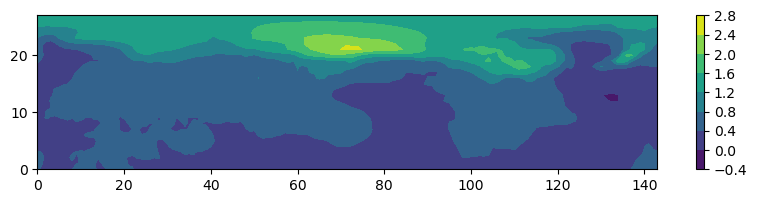

FileNotFoundError: [Errno 2] No such file or directory: '/glade/work/skygale/new_training/monthly_training/hist/arctic/GISS-E2-1-G.nc'

In [25]:
time_scale = 'monthly'
test_region = 'arctic'

# spliced check
path1 = '/glade/work/skygale/new_training/'+time_scale+'_training/spliced/'+test_region+'/CESM2.nc'
ds1 = xr.open_dataset(path1)
if time_scale == 'annual':
    test1 = ds1.X_SAT_SLP[:, :, :, :, 0]
else:
    test1 = ds1.X_SAT_SLP[:, :, 11, :, :, 0]

if test_region == 'arctic':
    plt.figure(figsize=(10, 2))
else:
    plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(test1[:, -6], 0))
plt.colorbar()
plt.show()

# hist check
path2 = '/glade/work/skygale/new_training/'+time_scale+'_training/hist/'+test_region+'/GISS-E2-1-G.nc'
ds2 = xr.open_dataset(path2)
if time_scale == 'annual':
    test2 = ds2.X_SAT_SLP[:, :, :, :, 0]
else:
    test2 = ds2.X_SAT_SLP[:, :, 11, :, :, 0]

if test_region == 'arctic':
    plt.figure(figsize=(10, 2))
else:
    plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(test2[:, -6], 0))
plt.colorbar()
plt.show()

## Observations

### SAT (1980-2022)

In [48]:
# paths = glob.glob('/pscratch/sd/s/skygale/observations/sat/*')
paths = glob.glob('/global/u2/s/skygale/workspace/Spring_AA_InternalVariability_project/updated-data/*_updated.nc')  # 1980-2024

for path in sorted(paths):
    obs_name = path.split('/')[8][:-11]
    print('Working on', obs_name)
    ds = xr.open_dataset(path)

    if obs_name == 'BerkeleyEarth':
        ds['time'] = ('time', fractional_year_to_datetime(ds['time'].values))
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_sat = ds.sel(time=slice('2000-01', '2024-12')).temperature
    if obs_name == 'GISTv4':
        ds_sat = ds.sel(time=slice('2000-01', '2024-12')).tempanomaly
    if obs_name == 'HadCRUTv5':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_sat = ds.sel(time=slice('2000-01', '2024-12')).tas_mean
    if obs_name == 'NOAAv6':
        ds_sat = ds.sel(time=slice('2000-01', '2024-12')).anom[:, 0]

    # interpolate using interpolate_na to nearest neighbor
    ds_interpolated = ds_sat.interpolate_na(dim='lat', method='nearest')

    '''
    # annual trend
    ds_annual = np.array(ds_interpolated)
    annual_to_fit = np.reshape(ds_annual, (ds_annual.shape[0], ds_annual.shape[1]*ds_annual.shape[2]))
    annual_trend_fit = np.polyfit(annual_fit, annual_to_fit, 1)[0]
    annual_trends_ = np.reshape(annual_trend_fit, ds_annual.shape[1:])

    # seasonal trends
    group_season = ds_interpolated.groupby('time.season')
    season_trend_fit = []
    for season in group_season.groups.keys():
        ds_season = np.array(group_season[season])
        season_to_fit = np.reshape(ds_season, (ds_season.shape[0], ds_season.shape[1]*ds_season.shape[2]))
        season_trend = np.polyfit(season_fit, season_to_fit, 1)[0]
        season_trend_fit.append(np.reshape(season_trend, (ds_season.shape[1:])))
    season_trends = np.stack(season_trend_fit, 0)
    '''

    # monthly trends
    group_month = ds_interpolated.groupby('time.month')
    month_trend_fit = []
    for month in group_month.groups.keys():
        ds_month = np.array(group_month[month])
        month_to_fit = np.reshape(ds_month, (ds_month.shape[0], ds_month.shape[1]*ds_month.shape[2]))
        month_trend = np.polyfit(month_fit, month_to_fit, 1)[0]
        month_trend_fit.append(np.reshape(month_trend, (ds_month.shape[1:])))
    month_trends = np.stack(month_trend_fit, 0)

    # regrid to 2.5 x 2.5 degree
    InputGrid = {"lon": ds.lon.values, "lat": ds.lat.values}
    OutputGrid = {"lon": lons, "lat": lats}
    regridder = xe.Regridder(InputGrid, OutputGrid, method="bilinear", periodic=True)
    # annual_trends = regridder(annual_trends_)
    # seasonal_trends = regridder(season_trends)
    monthly_trends = regridder(month_trends)

    # print(annual_trends.shape)
    # print(seasonal_trends.shape)
    print(monthly_trends.shape)

    # save as .nc file
    # obs_saver_annual('sat', obs_name, annual_trends, lats, lons)
    # obs_saver_seasonal('sat', obs_name, seasonal_trends, lats, lons)
    obs_saver_monthly('sat', obs_name, monthly_trends, lats, lons)

print('Done!')

Working on BerkeleyEarth
(12, 72, 144)
Working on GISTv4
(12, 72, 144)
Working on HadCRUTv5
(12, 72, 144)
Working on NOAAv6
(12, 72, 144)
Done!


### SLP (1980-2022)

In [4]:
paths = glob.glob('/pscratch/sd/s/skygale/observations/slp/*')

for path in sorted(paths):
    obs_name = path.split('/')[7][:-3]
    ds = xr.open_dataset(path)

    if obs_name == 'ERA5_TAS_PSL':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_slp = ds.sel(time=slice('2000-01', '2024-12')).msl
        obs_name = 'ERA5'
    if obs_name == 'JRA-55_TAS_SLP':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_slp = ds.sel(time=slice('2000-01', '2024-12')).Pressure_reduced_to_MSL_msl_Average 
        obs_name = 'JRA-55'
    if obs_name == 'MERRA-2_SLP':
        ds_slp = ds.sel(time=slice('2000-01', '2024-12')).SLP
        obs_name = 'MERRA-2'

    print('Working on', obs_name)

    # remove monthly slp climatology over given period
    slp_clim = ds_slp.groupby('time.month').mean('time')
    slp_clean = ds_slp.groupby('time.month') - slp_clim

    '''
    # annual trend
    ds_annual = np.array(slp_clean)
    annual_to_fit = np.reshape(ds_annual, (ds_annual.shape[0], ds_annual.shape[1]*ds_annual.shape[2]))
    annual_trend_fit = np.polyfit(annual_fit, annual_to_fit, 1)[0]
    annual_trends_ = np.reshape(annual_trend_fit, ds_annual.shape[1:])

    # seasonal trends
    group_season = slp_clean.groupby('time.season')
    season_trend_fit = []
    for season in group_season.groups.keys():
        ds_season = np.array(group_season[season])
        season_to_fit = np.reshape(ds_season, (ds_season.shape[0], ds_season.shape[1]*ds_season.shape[2]))
        season_trend = np.polyfit(season_fit, season_to_fit, 1)[0]
        season_trend_fit.append(np.reshape(season_trend, (ds_season.shape[1:])))
    season_trends = np.stack(season_trend_fit, 0)
    '''

    # monthly trends
    group_month = slp_clean.groupby('time.month')
    month_trend_fit = []
    for month in group_month.groups.keys():
        ds_month = np.array(group_month[month])
        month_to_fit = np.reshape(ds_month, (ds_month.shape[0], ds_month.shape[1]*ds_month.shape[2]))
        month_trend = np.polyfit(month_fit, month_to_fit, 1)[0]
        month_trend_fit.append(np.reshape(month_trend, (ds_month.shape[1:])))
    month_trends = np.stack(month_trend_fit, 0)

    # regrid to 2.5 x 2.5 degree
    InputGrid = {"lon": ds.lon.values, "lat": ds.lat.values}
    OutputGrid = {"lon": lons, "lat": lats}
    regridder = xe.Regridder(InputGrid, OutputGrid, method="bilinear", periodic=True)
    # annual_trends = regridder(annual_trends_)
    # seasonal_trends = regridder(season_trends)
    monthly_trends = regridder(month_trends)

    # print(annual_trends.shape)
    # print(seasonal_trends.shape)
    print(monthly_trends.shape)

    # save as .nc file
    # obs_saver_annual('slp', obs_name, annual_trends, lats, lons)
    # obs_saver_seasonal('slp', obs_name, seasonal_trends, lats, lons)
    obs_saver_monthly('slp', obs_name, monthly_trends, lats, lons)

print('Done!')

Working on ERA5


NameError: name 'ds_slp' is not defined

### AprMay

In [3]:
# script global variables
lats = np.arange(-88.75, 88.751, 2.5)
lons = np.arange(1.25, 358.751, 2.5)

# regression fit
season_fit = np.arange(0, 4.3, 1/20)

In [20]:
paths = glob.glob('/glade/work/skygale/raw_observations/SAT/*')
path = paths[2]
obs_name = path.split('/')[6][:-3]
path, obs_name

('/glade/work/skygale/raw_observations/SAT/ERA5_TAS_PSL.nc', 'ERA5_TAS_PSL')

In [31]:
paths = glob.glob('/glade/work/skygale/raw_observations/SAT/*')
paths = paths[2]

for path in [paths]:
    obs_name = path.split('/')[6][:-3]
    print('Working on', obs_name)
    ds = xr.open_dataset(path)

    if obs_name == 'BerkeleyEarth':
        ds['time'] = ('time', fractional_year_to_datetime(ds['time'].values))
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_sat = ds.sel(time=slice('1980-01', '2022-12')).temperature
    if obs_name == 'GISTv4':
        ds_sat = ds.sel(time=slice('1980-01', '2022-12')).tempanomaly
    if obs_name == 'HadCRUTv5':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_sat = ds.sel(time=slice('1980-01', '2022-12')).tas_mean
    if obs_name == 'NOAAv6':
        ds_sat = ds.sel(time=slice('1980-01', '2022-12')).anom[:, 0]
    if obs_name == 'ERA5_TAS_PSL':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_sat = ds.sel(time=slice('1980-01', '2022-12')).t2m
        obs_name = 'ERA5'

    # interpolate using interpolate_na to nearest neighbor
    if obs_name == 'ERA5':
        ds_interpolated = ds_sat
    else:
        ds_interpolated = ds_sat.interpolate_na(dim='lat', method='nearest')

    # group by month and filter for April and May (months 4 and 5)
    ds_AM = np.array(ds_interpolated.sel(time=ds_interpolated['time.month'].isin([4, 5])))
    AM_to_fit = np.reshape(ds_AM, (ds_AM.shape[0], ds_AM.shape[1]*ds_AM.shape[2]))
    AM_trend_fit = np.polyfit(season_fit, AM_to_fit, 1)[0]
    AM_trend = np.reshape(AM_trend_fit, (ds_AM.shape[1], ds_AM.shape[2]))

    # regrid to 2.5 x 2.5 degree
    InputGrid = {"lon": ds.lon.values, "lat": ds.lat.values}
    OutputGrid = {"lon": lons, "lat": lats}
    regridder = xe.Regridder(InputGrid, OutputGrid, method="bilinear", periodic=True)
    AM_trend_gridded = regridder(AM_trend)

    print(AM_trend_gridded.shape)

    # save as .nc file
    # obs_saver_seasonal('sat', obs_name, AM_trend_gridded, lats, lons)

print('Done!')

Working on ERA5_TAS_PSL
(72, 144)
Done!


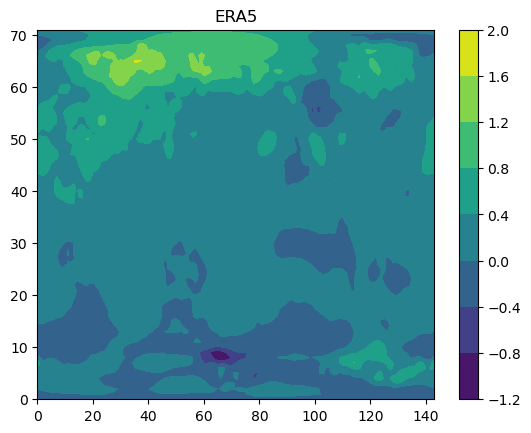

In [32]:
plt.contourf(AM_trend_gridded)
plt.title(f'{obs_name}')
plt.colorbar()
plt.show()

In [ ]:
paths = glob.glob('/glade/work/skygale/raw_observations/SLP/*')

for path in paths:
    obs_name = path.split('/')[6][:-3]
    print('Working on', obs_name)
    ds = xr.open_dataset(path)

    if obs_name == 'ERA5_TAS_PSL':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_slp = ds.sel(time=slice('1980-01', '2022-12')).msl
        obs_name = 'ERA5'
    if obs_name == 'JRA-55_TAS_SLP':
        ds = ds.rename({'latitude': 'lat', 'longitude': 'lon'})
        ds_slp = ds.sel(time=slice('1980-01', '2022-12')).Pressure_reduced_to_MSL_msl_Average 
        obs_name = 'JRA-55'
    if obs_name == 'MERRA-2_SLP':
        ds_slp = ds.sel(time=slice('1980-01', '2022-12')).SLP
        obs_name = 'MERRA-2'

    print(ds_slp)

    # remove monthly slp climatology over given period
    slp_clim = ds_slp.groupby('time.month').mean('time')
    slp_clean = ds_slp.groupby('time.month') - slp_clim

    # group by month and filter for April and May (months 4 and 5)
    ds_AM = np.array(slp_clean.sel(time=slp_clean['time.month'].isin([4, 5])))
    AM_to_fit = np.reshape(ds_AM, (ds_AM.shape[0], ds_AM.shape[1]*ds_AM.shape[2]))
    AM_trend_fit = np.polyfit(season_fit, AM_to_fit, 1)[0]
    AM_trend = np.reshape(AM_trend_fit, (ds_AM.shape[1], ds_AM.shape[2]))

    # regrid to 2.5 x 2.5 degree
    InputGrid = {"lon": ds.lon.values, "lat": ds.lat.values}
    OutputGrid = {"lon": lons, "lat": lats}
    regridder = xe.Regridder(InputGrid, OutputGrid, method="bilinear", periodic=True)
    AM_trend_gridded = regridder(AM_trend)

    print(AM_trend_gridded.shape)

    # save as .nc file
    obs_saver_seasonal('slp', obs_name, AM_trend_gridded, lats, lons)

print('Done!')

Working on MERRA-2_SLP
<xarray.DataArray 'SLP' (time: 516, lat: 361, lon: 576)>
[107294976 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 -90.0 -89.5 -89.0 -88.5 -88.0 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * time     (time) datetime64[ns] 1980-01-01 1980-02-01 ... 2022-12-01
Attributes:
    long_name:       Sea-level pressure
    units:           Pa
    fmissing_value:  1000000000000000.0
    vmax:            1000000000000000.0
    vmin:            -1000000000000000.0
    valid_range:     [-1.e+15  1.e+15]
    origname:        SLP
    fullnamepath:    /SLP


## MMM

### Annual

In [404]:
for path in sorted(paths):
    model_name = path.split('/')[6][:-3]
    print('Working on', model_name)

    ds = xr.open_dataset(path)
    M = len(ds.member.values)

    # load data
    if region == 'arctic':
        ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
        ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
    if region == 'global':
        ds_sat = ds.SAT_SLP[:, :, :, :, :, 1]  # (M, Y, 12, 72, 144)
        ds_slp = ds.SAT_SLP[:, :, :, :, :, 0]  # (M, Y, 12, 72, 144)

    # allocate all data
    sat_annual = []
    slp_annual = []

    for member in range(0, M):
        sat_member = ds_sat[member]
        slp_member = ds_slp[member]

        for p, period in enumerate(periods):
            sat_cut = sat_member.sel(year=slice(period, period+42))
            slp_cut = slp_member.sel(year=slice(period, period+42))

            # remove monthly sat climatology over given period
            sat_clim = sat_cut.groupby('month').mean('year')
            sat_clean = sat_cut - sat_clim

            # remove monthly slp climatology over given period
            slp_clim = slp_cut.groupby('month').mean('year')
            slp_clean = slp_cut - slp_clim

            # sat annual
            sat = np.array(sat_clean)
            sat_annual_to_fit = np.reshape(sat, (sat.shape[0]*sat.shape[1], sat.shape[2]*sat.shape[3]))
            sat_annual_trend_fit = np.polyfit(annual_fit, sat_annual_to_fit, 1)[0]
            sat_annual_trends = np.reshape(sat_annual_trend_fit, (sat.shape[2:]))
            sat_annual.append(sat_annual_trends)

            # slp annual
            slp = np.array(slp_clean)
            slp_annual_to_fit = np.reshape(slp, (slp.shape[0]*slp.shape[1], slp.shape[2]*slp.shape[3]))
            slp_annual_trend_fit = np.polyfit(annual_fit, slp_annual_to_fit, 1)[0]
            slp_annual_trends = np.reshape(slp_annual_trend_fit, (slp.shape[2:]))
            slp_annual.append(slp_annual_trends)

    # reshape into members, periods,...
    sat_trend_all = np.reshape(sat_annual, (M, P, sat.shape[2], sat.shape[3]))
    slp_trend_all = np.reshape(slp_annual, (M, P, slp.shape[2], slp.shape[3]))

    # combine data
    sat_slp = [sat_trend_all, slp_trend_all]  # (2, M, P, 28/72, 144)
    sat_slp = np.moveaxis(sat_slp, 0, -1)     # (M, P, 28/72, 144, 2)
    print('SAT_SLP:', np.shape(sat_slp))

    # I_E_SUM
    # external
    if region == 'arctic':
        sat_trend_cut = sat_trend_all[:, :, 20:]
    if region == 'global':
        sat_trend_cut = sat_trend_all
    forced_trend = np.nanmean(sat_trend_cut, 0)

    # internal
    internal_trends = sat_trend_cut - forced_trend

    # weighted spatial averages
    if region == 'arctic':
        external = weighted_spatial(forced_trend, lats[64:])
        internal = weighted_spatial(internal_trends, lats[64:])
        sum = weighted_spatial(sat_trend_cut, lats[64:])
    if region == 'global':
        external = weighted_spatial(forced_trend, lats)
        internal = weighted_spatial(internal_trends, lats)
        sum = weighted_spatial(sat_trend_cut, lats)

    # fix external shape for array combining
    forced = np.zeros([M, P])
    for p in range(P):
        forced[:, p] = external[p]

    # combine and reshape axes
    i_e_sum = [internal, forced, sum]      # (3, M, P)
    i_e_sum = np.moveaxis(i_e_sum, 0, -1)  # (M, P, 3)
    print('I_E_SUM:', np.shape(i_e_sum))

    # save as .nc file
    if region == 'arctic':
        mod_saver_annual(type, region, model_name, M, P, periods, lats[44:], lons, sat_slp, i_e_sum)
    if region == 'global':
        mod_saver_annual(type, region, model_name, M, P, periods, lats, lons, sat_slp, i_e_sum)

print('Done!')

Working on GISS-E2-1-G
SAT_SLP: (12, 24, 72, 144, 2)
I_E_SUM: (12, 24, 3)
Working on GISS-E2-1-H
SAT_SLP: (10, 24, 72, 144, 2)
I_E_SUM: (10, 24, 3)
Working on MPI-ESM1-2-HR
SAT_SLP: (10, 24, 72, 144, 2)
I_E_SUM: (10, 24, 3)
Working on NorCPM1
SAT_SLP: (29, 24, 72, 144, 2)
I_E_SUM: (29, 24, 3)
Working on OthersAllEM
SAT_SLP: (20, 24, 72, 144, 2)
I_E_SUM: (20, 24, 3)
Done!


#### Figuring out climatology and data

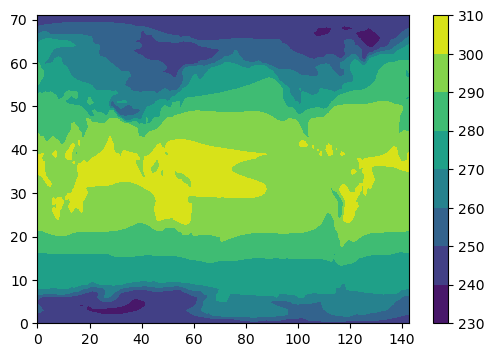

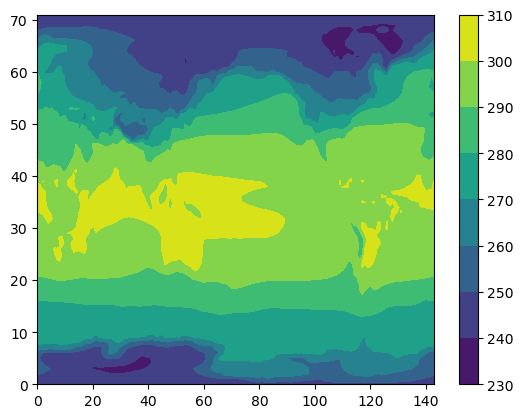

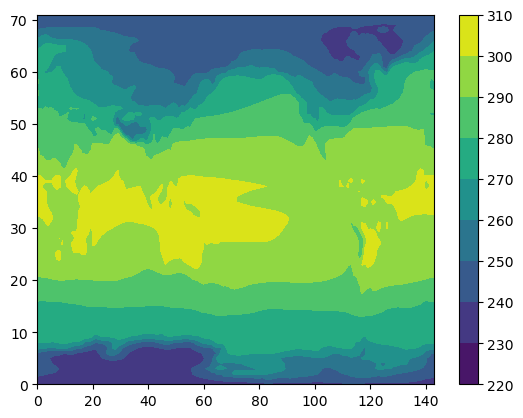

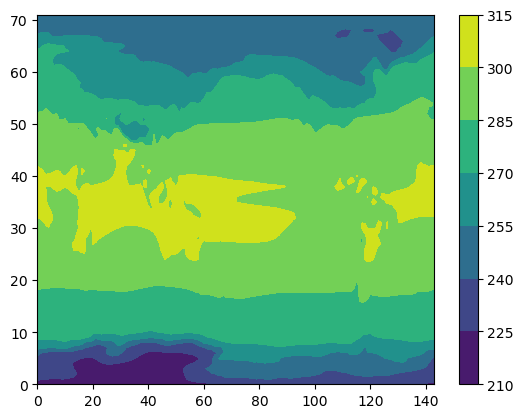

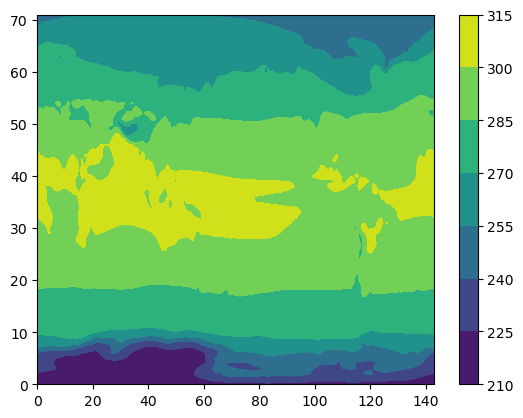

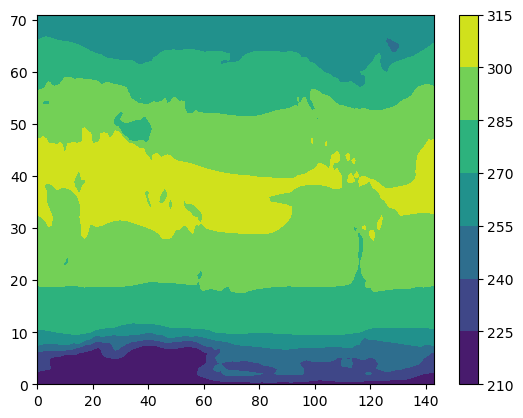

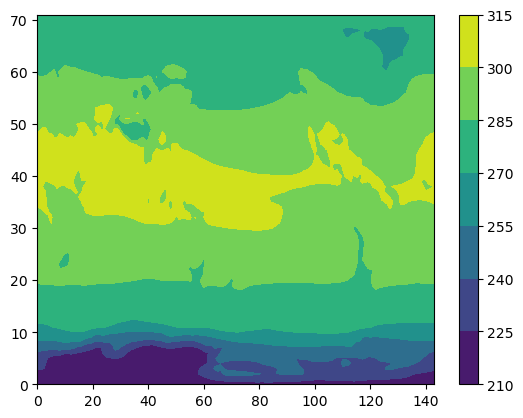

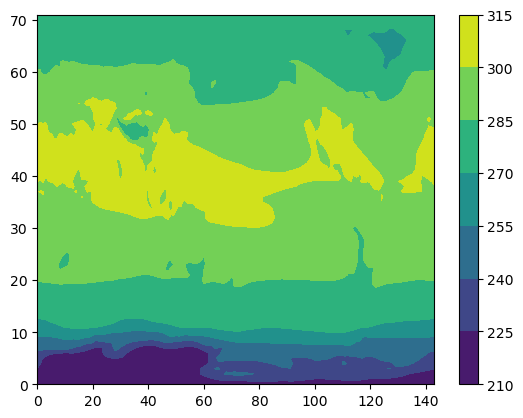

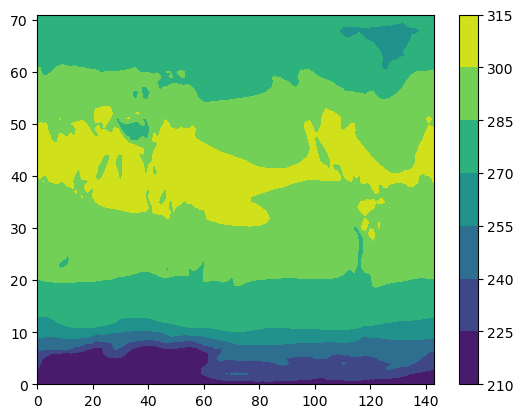

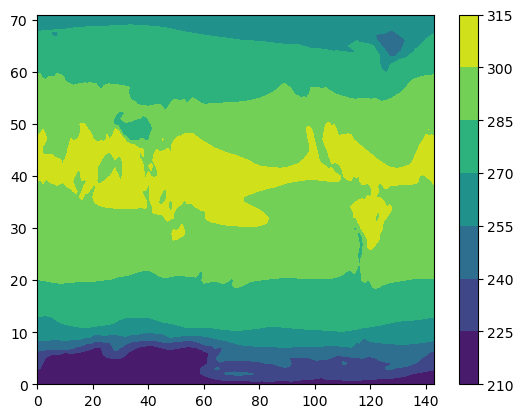

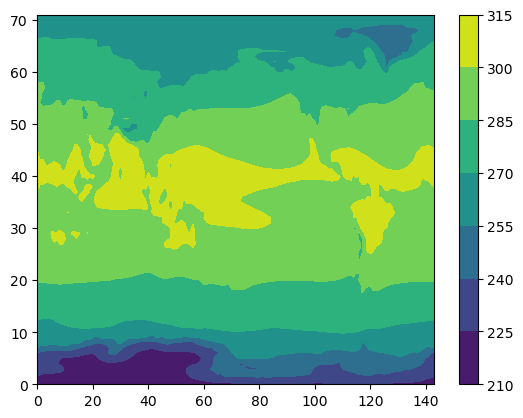

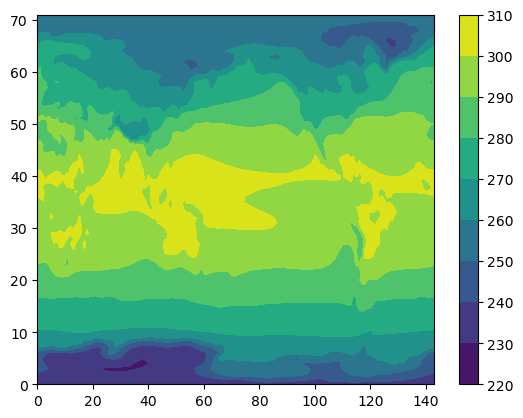

In [251]:
sat = ds.SAT_SLP[:, :, :, :, :, 1]
subset = sat.sel(year=slice(1980, 2022))
plt.figure(figsize=(6, 4))
for i in range(12):
    plt.contourf(np.nanmean(subset[:, 0, i], 0))
    plt.colorbar()
    plt.show()

In [237]:
annual_climatology = subset.groupby('year').mean(dim='month')
subset_test = subset - annual_climatology

In [260]:
monthly_climatology = subset.groupby('month').mean('year')
subset_test2 = subset - monthly_climatology

In [246]:
np.nanmean(subset_test[:, 0], (0, 1)).shape

(72, 144)

In [261]:
np.nanmean(subset_test2[:, 0], (0, 1)).shape

(72, 144)

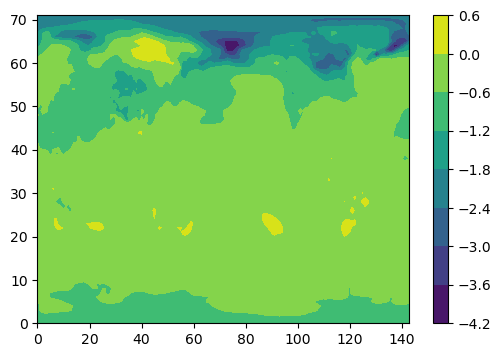

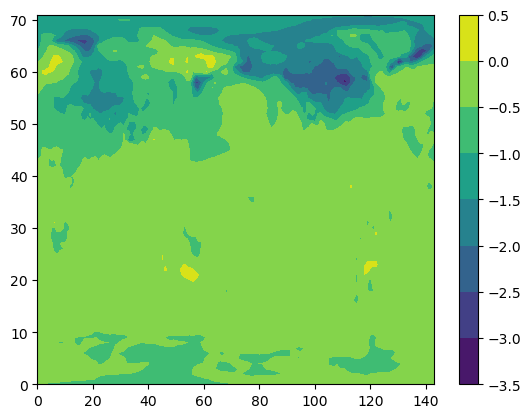

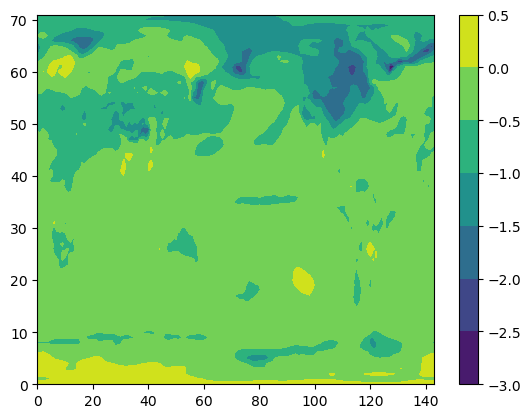

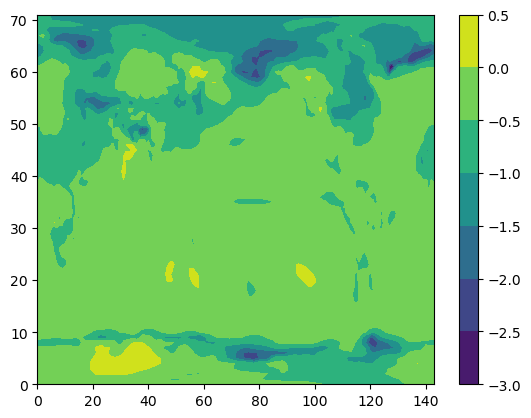

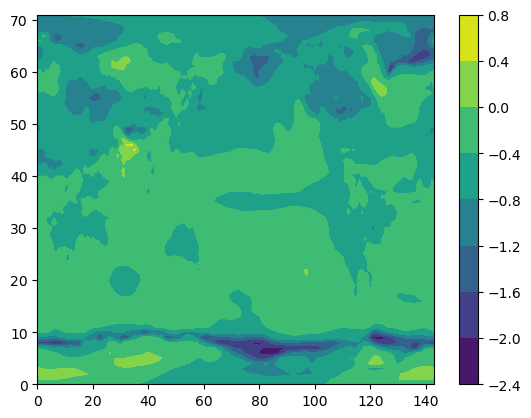

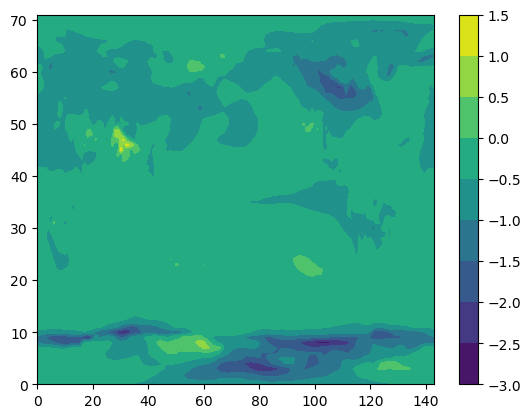

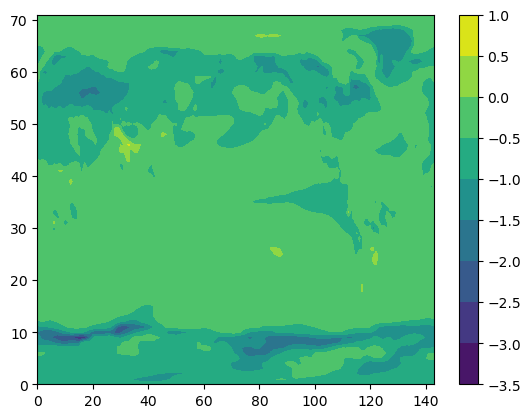

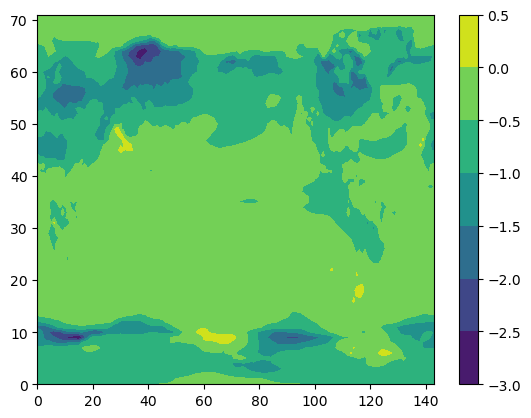

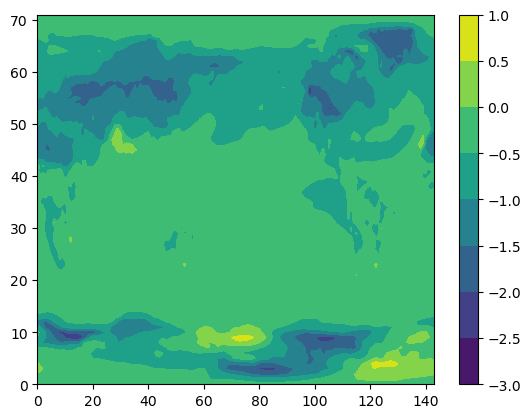

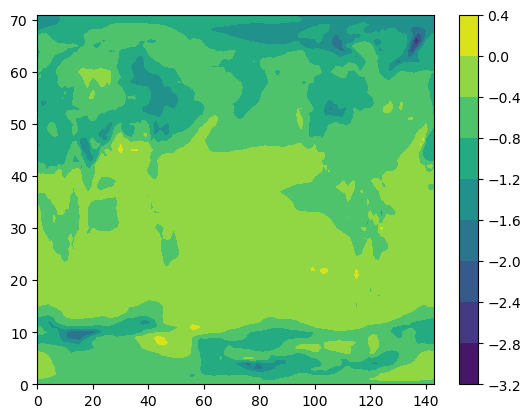

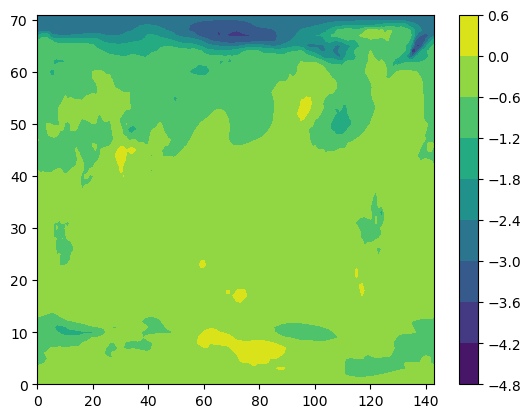

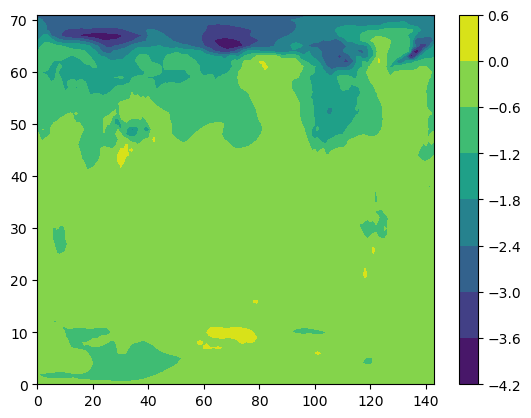

In [262]:
plt.figure(figsize=(6, 4))
for i in range(12):
    plt.contourf(np.nanmean(subset_test2[:, 0, i], 0))
    plt.colorbar()
    plt.show()

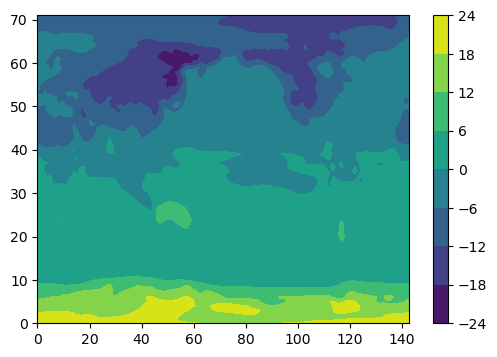

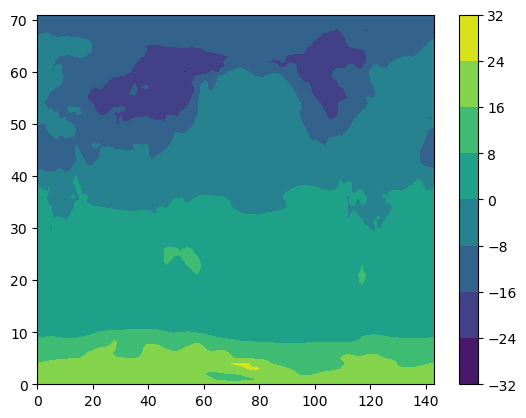

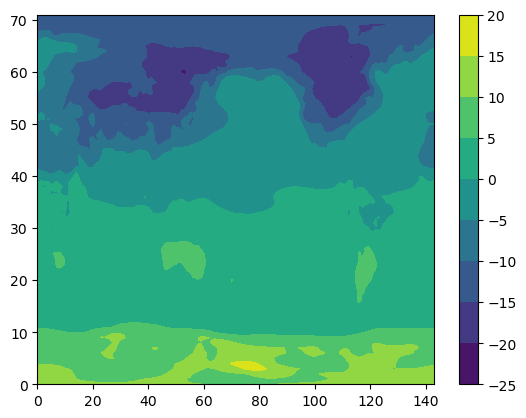

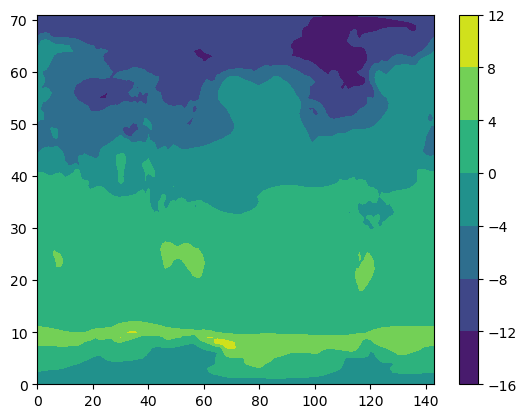

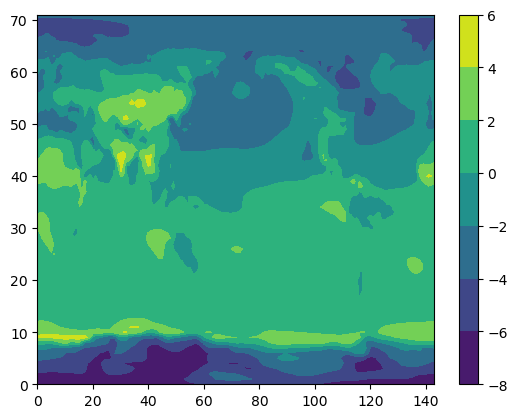

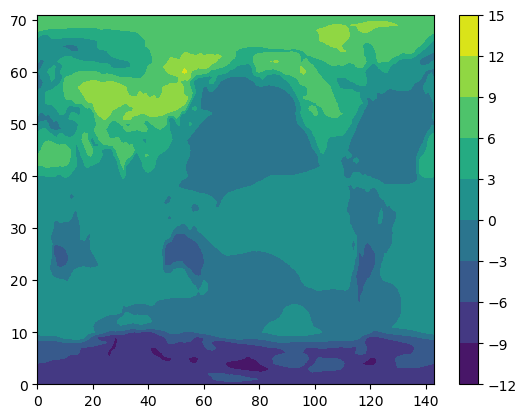

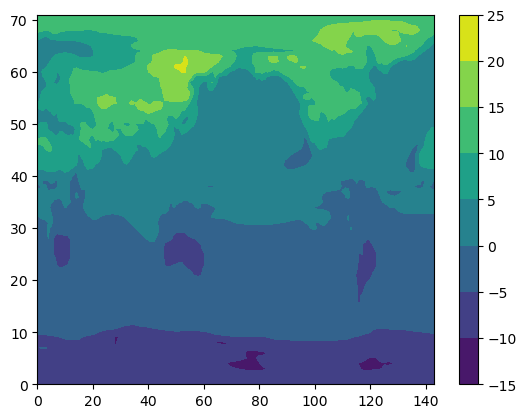

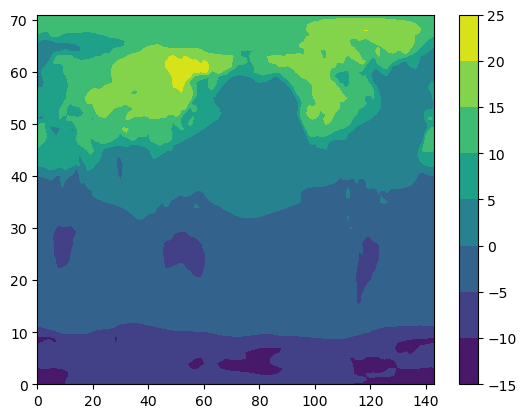

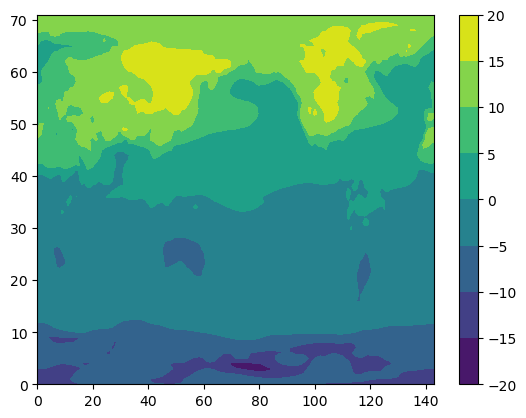

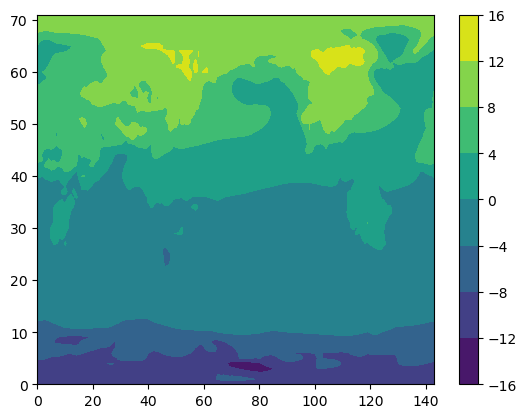

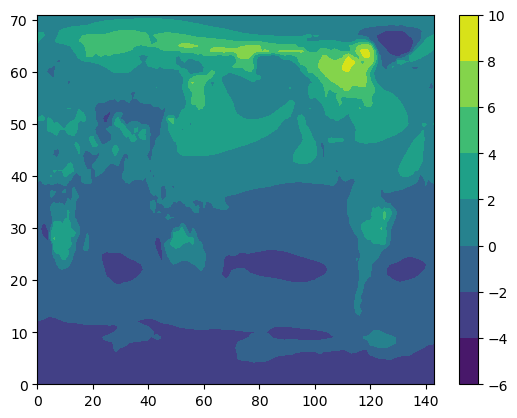

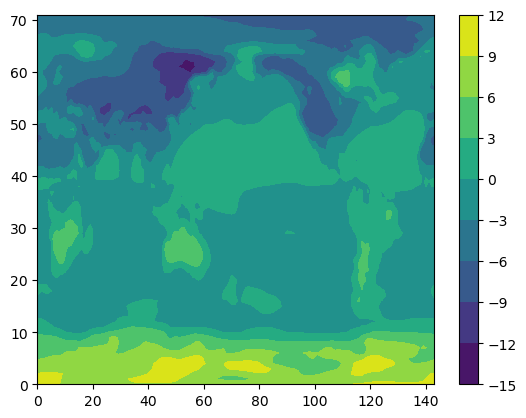

In [250]:
plt.figure(figsize=(6, 4))
for i in range(12):
    plt.contourf(np.nanmean(subset_test[:, 0, i], 0))
    plt.colorbar()
    plt.show()

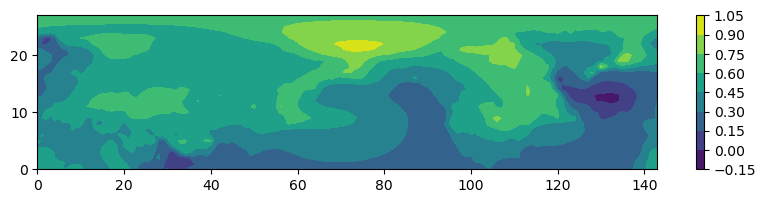

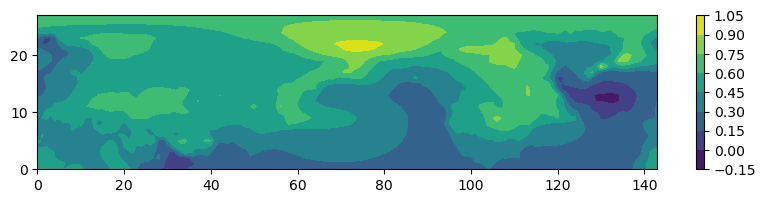

In [264]:
plt.figure(figsize=(10, 2))
plt.contourf(np.nanmean(sat_trend_all[:, -6], 0))
plt.colorbar()
plt.show()

test = xr.open_dataset('/glade/work/skygale/old_training/ssp_processed/arctic/CESM2.nc')
plt.figure(figsize=(10, 2))
plt.contourf(np.nanmean(test.X_SAT_SLP[:, -6, :, :, :, 0], (0, 1)))
plt.colorbar()
plt.show()

In [265]:
data_array = forced_trend
lats_new = lats[64:]
forced_trend[-6].shape, data_array.shape, lats_new.shape

((8, 144), (31, 8, 144), (8,))

In [270]:
weights = np.cos(np.deg2rad(lats_new))
weighted_data_array = np.multiply(data_array, weights[np.newaxis, :, np.newaxis])
shape = np.shape(weighted_data_array)
weighted_data_reshaped = np.reshape(weighted_data_array, (shape[0], shape[1]*shape[2]))
weighted_sum = np.nansum(weighted_data_reshaped, 1)
denom = np.nansum(weights)*144
weighted_divide = np.divide(weighted_sum, denom)
print(weighted_divide[-6])
print(weighted_divide)

0.62652065463334
[0.07761648 0.05527001 0.01868674 0.01302813 0.02530697 0.07446362
 0.13432275 0.13354666 0.1762554  0.22481071 0.24828307 0.23322594
 0.20313196 0.17531119 0.11479454 0.06559961 0.05667118 0.11627804
 0.17106905 0.25970956 0.30543853 0.44137229 0.59153236 0.6834155
 0.68281616 0.62652065 0.55434527 0.50415051 0.45901618 0.42810294
 0.49838651]


In [272]:
np.nanmean(i_e_sum[:, -6, 1])

0.3132603273166699

In [268]:
test = xr.open_dataset('/glade/work/skygale/old_training/ssp_processed/arctic/CESM2.nc')
ann = np.nanmean(test.Y_I_E_SUM, 2)
print(ann[:, :, 1].shape, np.nanmean(ann[:, -6, 1]))

(50, 31) 0.62685734


In [283]:
test1 = xr.open_dataset('/glade/work/skygale/new_training/annual_training/spliced/arctic/CESM2.nc')
print(test1.Y_I_E_SUM[:, :, 1].shape, np.nanmean(test1.Y_I_E_SUM[:, -6, 1]))

(50, 31) 0.62652063


### Seasonal

#### Original

In [10]:
for path in sorted(paths):
    model_name = path.split('/')[7][:-3]
    print('Working on', model_name)

    ds = xr.open_dataset(path)
    M = len(ds.member.values)

    # load data
    if region == 'arctic':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
    if region == 'global':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 1]    # (M, Y, 12, 72, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 0]    # (M, Y, 12, 72, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 0]    # (M, Y, 12, 72, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 1]    # (M, Y, 12, 72, 144)

    # allocate all data
    sat_seasonal = []
    slp_seasonal = []

    for member in range(0, M):
        sat_member = ds_sat[member]
        slp_member = ds_slp[member]

        for p, period in enumerate(periods):
            sat_cut = sat_member.sel(year=slice(period, period+42))
            slp_cut = slp_member.sel(year=slice(period, period+42))

            # remove monthly sat climatology over given period
            sat_clim = sat_cut.groupby('month').mean('year')
            sat_clean = sat_cut - sat_clim

            # remove monthly slp climatology over given period
            slp_clim = slp_cut.groupby('month').mean('year')
            slp_clean = slp_cut - slp_clim

            # sat seasonal
            sat_DJF = sat_clean.isel(month=[-1, 0, 1])
            sat_MAM = sat_clean.isel(month=[2, 3, 4])
            sat_JJA = sat_clean.isel(month=[5, 6, 7])
            sat_SON = sat_clean.isel(month=[8, 9, 10])
            sat_group_seasons = np.array([sat_DJF, sat_MAM, sat_JJA, sat_SON])

            sat_season_trend_fit = []
            for season in range(len(sat_group_seasons)):
                sat_ds_season = np.array(sat_group_seasons[season])
                s = np.shape(sat_ds_season)
                sat_season_to_fit = np.reshape(sat_ds_season, (s[0]*s[1], s[2]*s[3]))
                sat_season_trend = np.polyfit(season_fit, sat_season_to_fit, 1)[0]
                sat_season_trend_fit.append(np.reshape(sat_season_trend, (s[2:])))

            # append to all trend array
            sat_seasonal.append(sat_season_trend_fit)

            # slp seasonal
            slp_DJF = slp_clean.isel(month=[-1, 0, 1])
            slp_MAM = slp_clean.isel(month=[2, 3, 4])
            slp_JJA = slp_clean.isel(month=[5, 6, 7])
            slp_SON = slp_clean.isel(month=[8, 9, 10])
            slp_group_seasons = np.array([slp_DJF, slp_MAM, slp_JJA, slp_SON])

            slp_season_trend_fit = []
            for season in range(len(slp_group_seasons)):
                slp_ds_season = np.array(slp_group_seasons[season])
                s = np.shape(slp_ds_season)
                slp_season_to_fit = np.reshape(slp_ds_season, (s[0]*s[1], s[2]*s[3]))
                slp_season_trend = np.polyfit(season_fit, slp_season_to_fit, 1)[0]
                slp_season_trend_fit.append(np.reshape(slp_season_trend, (s[2:])))

            # append to all trend array
            slp_seasonal.append(slp_season_trend_fit)

    # reshape into members, periods,...
    sat_trend_all = np.reshape(sat_seasonal, (M, P, 4, s[2], s[3]))
    slp_trend_all = np.reshape(slp_seasonal, (M, P, 4, s[2], s[3]))

    # combine data
    sat_slp = [sat_trend_all, slp_trend_all]  # (2, M, P, 4, 72, 144)
    sat_slp = np.moveaxis(sat_slp, 0, -1)     # (M, P, 4, 72, 144, 2)
    print('SAT_SLP:', np.shape(sat_slp))

    # I_E_SUM
    # external
    if region == 'arctic':
        slp_trend_cut = slp_trend_all[:, :, :, 20:]
    if region == 'global':
        slp_trend_cut = slp_trend_all
    forced_trend = np.nanmean(slp_trend_cut, 0)

    # internal
    internal_trends = slp_trend_cut - forced_trend

    # weighted spatial averages
    if region == 'arctic':
        external = weighted_spatial(forced_trend, lats[64:])
        internal = weighted_spatial(internal_trends, lats[64:])
        sum = weighted_spatial(slp_trend_cut, lats[64:])
    if region == 'global':
        external = weighted_spatial(forced_trend, lats)
        internal = weighted_spatial(internal_trends, lats)
        sum = weighted_spatial(slp_trend_cut, lats)

    # fix external shape for array combining
    forced = np.zeros([M, P, 4])
    for p in range(P):
        for i in range(4):
            forced[:, p, i] = external[p, i]

    # combine and reshape axes
    i_e_sum = [internal, forced, sum]      # (3, M, P, 4)
    i_e_sum = np.moveaxis(i_e_sum, 0, -1)  # (M, P, 4, 3)
    print('I_E_SUM:', np.shape(i_e_sum))

    # save as .nc file
    if region == 'arctic':
        mod_saver_seasonal(type, region, model_name, M, P, periods, lats[44:], lons, sat_slp, i_e_sum)
    if region == 'global':
        mod_saver_seasonal(type, region, model_name, M, P, periods, lats, lons, sat_slp, i_e_sum)

print('Done!')

Working on ACCESS-ESM1-5
SAT_SLP: (25, 31, 4, 28, 144, 2)
I_E_SUM: (25, 31, 4, 3)
Working on CESM2
SAT_SLP: (50, 31, 4, 28, 144, 2)
I_E_SUM: (50, 31, 4, 3)
Working on CESM2_SMBB
SAT_SLP: (50, 31, 4, 28, 144, 2)
I_E_SUM: (50, 31, 4, 3)
Working on CanESM5
SAT_SLP: (25, 31, 4, 28, 144, 2)
I_E_SUM: (25, 31, 4, 3)
Working on E3SM-2-0
SAT_SLP: (21, 31, 4, 28, 144, 2)
I_E_SUM: (21, 31, 4, 3)
Working on IPSL-CM6A-LR
SAT_SLP: (11, 31, 4, 28, 144, 2)
I_E_SUM: (11, 31, 4, 3)
Working on MIROC6
SAT_SLP: (50, 31, 4, 28, 144, 2)
I_E_SUM: (50, 31, 4, 3)
Working on MPI-ESM1-2-LR
SAT_SLP: (10, 31, 4, 28, 144, 2)
I_E_SUM: (10, 31, 4, 3)
Working on OthersAllEM
SAT_SLP: (79, 31, 4, 28, 144, 2)
I_E_SUM: (79, 31, 4, 3)
Done!


#### April and May Only

In [24]:
# define processing type and region
type = 'spliced'
region = 'arctic'

# paths to CMIP6 data
paths = glob.glob('/glade/work/skygale/new_mydata/'+type+'/*')

if type == 'spliced':
    periods = np.arange(1855, 2010, 5)
if type == 'hist':
    periods = np.arange(1855, 1975, 5)

# script global variables
P = len(periods)
lats = np.arange(-88.75, 88.751, 2.5)
lons = np.arange(1.25, 358.751, 2.5)

# regression fit
season_fit = np.arange(0, 4.3, 1/20)
type, P, region

('spliced', 31, 'arctic')

In [25]:
for path in sorted(paths):
    model_name = path.split('/')[6][:-3]
    print('Working on', model_name)

    ds = xr.open_dataset(path)
    M = len(ds.member.values)

    # load data
    if region == 'arctic':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
    if region == 'global':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 1]    # (M, Y, 12, 72, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 0]    # (M, Y, 12, 72, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 0]    # (M, Y, 12, 72, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 1]    # (M, Y, 12, 72, 144)

    # allocate all data
    sat_AM = []
    slp_AM = []

    for member in range(0, M):
        sat_member = ds_sat[member]
        slp_member = ds_slp[member]

        for p, period in enumerate(periods):
            sat_cut = sat_member.sel(year=slice(period, period+42))
            slp_cut = slp_member.sel(year=slice(period, period+42))

            # remove monthly sat climatology over given period
            sat_clim = sat_cut.groupby('month').mean('year')
            sat_clean = sat_cut - sat_clim

            # remove monthly slp climatology over given period
            slp_clim = slp_cut.groupby('month').mean('year')
            slp_clean = slp_cut - slp_clim

            # sat AM
            sat_ds_AM = np.array(sat_clean.isel(month=[3, 4]))
            s = np.shape(sat_ds_AM)
            sat_AM_to_fit = np.reshape(sat_ds_AM, (s[0]*s[1], s[2]*s[3]))
            sat_AM_trend = np.polyfit(season_fit, sat_AM_to_fit, 1)[0]
            sat_AM.append(np.reshape(sat_AM_trend, (s[2:])))

            # slp AM
            slp_ds_AM = np.array(slp_clean.isel(month=[3, 4]))
            s = np.shape(slp_ds_AM)
            slp_AM_to_fit = np.reshape(slp_ds_AM, (s[0]*s[1], s[2]*s[3]))
            slp_AM_trend = np.polyfit(season_fit, slp_AM_to_fit, 1)[0]
            slp_AM.append(np.reshape(slp_AM_trend, (s[2:])))

    # reshape into members, periods,...
    sat_trend_all = np.reshape(sat_AM, (M, P, s[2], s[3]))
    slp_trend_all = np.reshape(slp_AM, (M, P, s[2], s[3]))

    # combine data
    sat_slp = [sat_trend_all, slp_trend_all]  # (2, M, P, 72, 144)
    sat_slp = np.moveaxis(sat_slp, 0, -1)     # (M, P, 72, 144, 2)
    print('SAT_SLP:', np.shape(sat_slp))

    # I_E_SUM
    # external
    if region == 'arctic':
        sat_trend_cut = sat_trend_all[:, :, 20:]
    if region == 'global':
        sat_trend_cut = sat_trend_all
    forced_trend = np.nanmean(sat_trend_cut, 0)

    # internal
    internal_trends = sat_trend_cut - forced_trend

    # weighted spatial averages
    if region == 'arctic':
        external = weighted_spatial(forced_trend, lats[64:])
        internal = weighted_spatial(internal_trends, lats[64:])
        sum = weighted_spatial(sat_trend_cut, lats[64:])
    if region == 'global':
        external = weighted_spatial(forced_trend, lats)
        internal = weighted_spatial(internal_trends, lats)
        sum = weighted_spatial(sat_trend_cut, lats)

    # fix external shape for array combining
    forced = np.zeros([M, P])
    for p in range(P):
        forced[:, p] = external[p]

    # combine and reshape axes
    i_e_sum = [internal, forced, sum]      # (3, M, P)
    i_e_sum = np.moveaxis(i_e_sum, 0, -1)  # (M, P, 3)
    print('I_E_SUM:', np.shape(i_e_sum))

    # save as .nc file
    if region == 'arctic':
        mod_saver_seasonal(type, region, model_name, M, P, periods, lats[44:], lons, sat_slp, i_e_sum)
    if region == 'global':
        mod_saver_seasonal(type, region, model_name, M, P, periods, lats, lons, sat_slp, i_e_sum)

print('Done!')

Working on ACCESS-ESM1-5
SAT_SLP: (25, 31, 28, 144, 2)
I_E_SUM: (25, 31, 3)
Working on CESM2
SAT_SLP: (50, 31, 28, 144, 2)
I_E_SUM: (50, 31, 3)
Working on CESM2_SMBB
SAT_SLP: (50, 31, 28, 144, 2)
I_E_SUM: (50, 31, 3)
Working on CanESM5
SAT_SLP: (25, 31, 28, 144, 2)
I_E_SUM: (25, 31, 3)
Working on E3SM-2-0
SAT_SLP: (21, 31, 28, 144, 2)
I_E_SUM: (21, 31, 3)
Working on IPSL-CM6A-LR
SAT_SLP: (11, 31, 28, 144, 2)
I_E_SUM: (11, 31, 3)
Working on MIROC6
SAT_SLP: (50, 31, 28, 144, 2)
I_E_SUM: (50, 31, 3)
Working on MPI-ESM1-2-LR
SAT_SLP: (10, 31, 28, 144, 2)
I_E_SUM: (10, 31, 3)
Working on OthersAllEM
SAT_SLP: (79, 31, 28, 144, 2)
I_E_SUM: (79, 31, 3)
Done!


#### Figuring out climatology

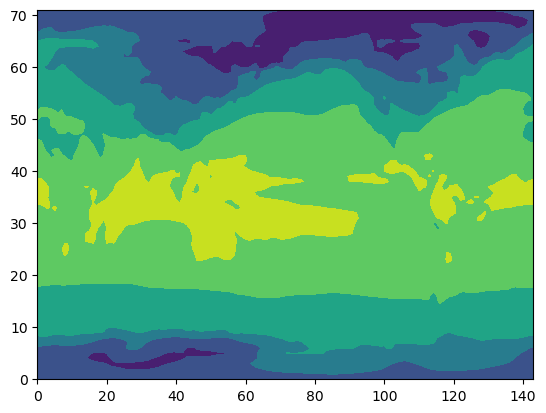

In [342]:
fixing = ds.SAT_SLP
plt.contourf(fixing[0, 0, 0, :, :, 0])

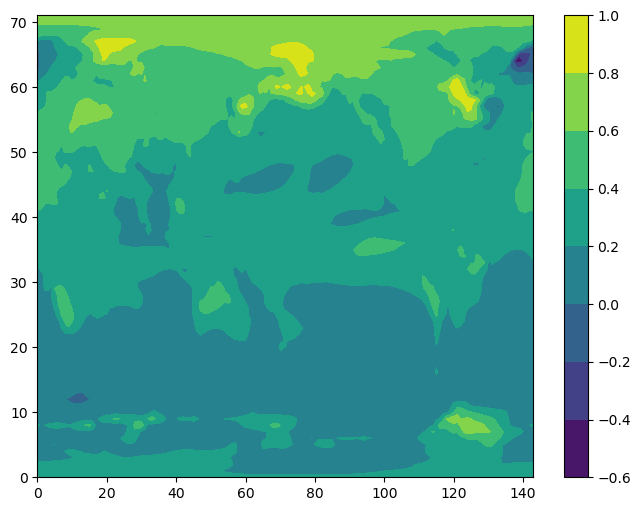

In [344]:
plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(sat_trend_all[:, -6, 1, :, :], 0))
plt.colorbar()
plt.show()

In [345]:
sat_trend_cut.shape, forced_trend.shape, external.shape

((25, 31, 4, 72, 144), (31, 4, 72, 144), (31, 4))

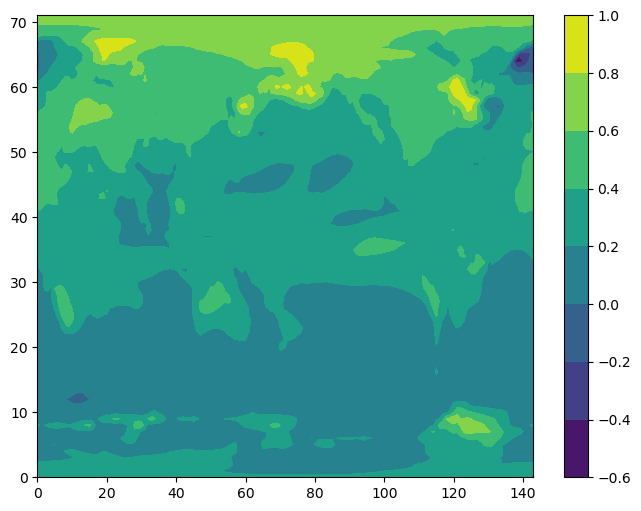

In [346]:
test = xr.open_dataset('/glade/work/skygale/old_training/ssp_processed/global/ACCESS-ESM1-5.nc')
test_sat = test.X_SAT_SLP[:, -6, :, :, :, 0]
test_spring = test_sat.isel(month=[2, 3, 4])
plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(test_spring, (0, 1)))
plt.colorbar()
plt.show()

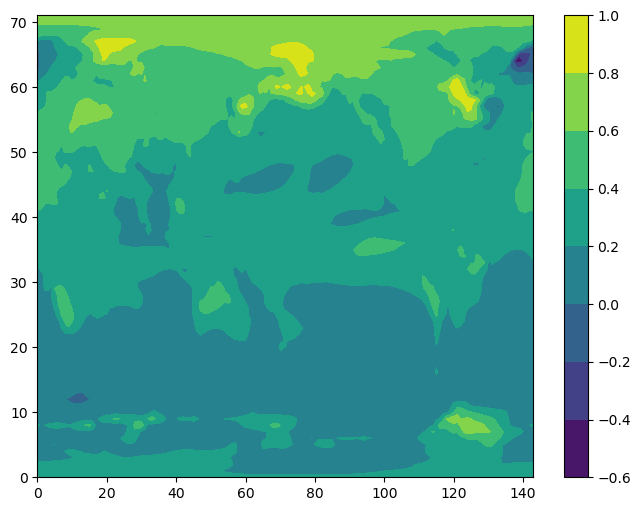

In [348]:
plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(sat_slp[:, -6, 1, :, :, 0], 0))
plt.colorbar()
plt.show()

In [349]:
test_ext = test.Y_I_E_SUM[:, -6, [2, 3, 4], 1]
np.nanmean(test_ext)

0.26197302

In [350]:
i_e_sum[:, -6, 1, 1].shape, np.nanmean(i_e_sum[:, -6, 1, 1])

((25,), 0.2618470663802805)

In [351]:
np.nanmean(external, 0)

array([0.10308512, 0.09396302, 0.09476941, 0.10210995])

### Monthly

In [29]:
for path in sorted(paths):
    model_name = path.split('/')[8][:-3]
    print('Working on', model_name)

    ds = xr.open_dataset(path)
    members = ds.member.values
    M = len(members)

    # load data
    if region == 'arctic':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, 44:, :, 0]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, 44:, :, 1]  # (M, Y, 12, 28, 144)
    if region == 'global':
        if model_name in ['CESM2', 'CESM2_SMBB']:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 1]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 0]  # (M, Y, 12, 28, 144)
        else:
            ds_sat = ds.SAT_SLP[:, :, :, :, :, 0]  # (M, Y, 12, 28, 144)
            ds_slp = ds.SAT_SLP[:, :, :, :, :, 1]  # (M, Y, 12, 28, 144)
    
    # allocate all data
    sat_monthly = []
    slp_monthly = []

    for member in range(len(members)):
        sat = ds_sat[member]
        slp = ds_slp[member]

        for p, period in enumerate(periods):
            sat_cut = sat.sel(year=slice(period, period+24))
            slp_cut = slp.sel(year=slice(period, period+24))

            # remove monthly sat climatology over given period
            sat_clim = sat_cut.groupby('month').mean('year')
            sat_clean = sat_cut - sat_clim

            # remove monthly slp climatology over given period
            slp_clim = slp_cut.groupby('month').mean('year')
            slp_clean = slp_cut - slp_clim

            # sat monthly
            sat_group_months = sat_clean.groupby('month')

            sat_month_trend_fit = []
            for month in range(len(sat_group_months)):
                sat_ds_month = np.array(sat_group_months[month][:, 0])
                s = np.shape(sat_ds_month)
                sat_month_to_fit = np.reshape(sat_ds_month, (s[0], s[1]*s[2]))
                sat_month_trend = np.polyfit(month_fit, sat_month_to_fit, 1)[0]
                sat_month_trend_fit.append(np.reshape(sat_month_trend, (s[1:])))

            # append to all trend array
            sat_monthly.append(sat_month_trend_fit)

            # slp monthly
            slp_group_months = slp_clean.groupby('month')

            slp_month_trend_fit = []
            for month in range(len(slp_group_months)):
                slp_ds_month = np.array(slp_group_months[month][:, 0])
                s = np.shape(slp_ds_month)
                slp_month_to_fit = np.reshape(slp_ds_month, (s[0], s[1]*s[2]))
                slp_month_trend = np.polyfit(month_fit, slp_month_to_fit, 1)[0]
                slp_month_trend_fit.append(np.reshape(slp_month_trend, (s[1:])))

            # append to all trend array
            slp_monthly.append(slp_month_trend_fit)

    # reshape into members, periods,...
    sat_trend_all = np.reshape(sat_monthly, (M, P, 12, s[1], s[2]))
    slp_trend_all = np.reshape(slp_monthly, (M, P, 12, s[1], s[2]))

    # combine data
    sat_slp = [sat_trend_all, slp_trend_all]  # (2, M, P, 12, 72, 144)
    sat_slp = np.moveaxis(sat_slp, 0, -1)     # (M, P, 12, 72, 144, 2)
    print('SAT_SLP:', np.shape(sat_slp))

    # I_E_SUM
    # external
    if region == 'arctic':
        sat_trend_cut = sat_trend_all[:, :, :, 20:]
    if region == 'global':
        sat_trend_cut = sat_trend_all
    forced_trend = np.nanmean(sat_trend_cut, 0)

    # internal
    internal_trends = sat_trend_cut - forced_trend

    # weighted spatial averages
    if region == 'arctic':
        external = weighted_spatial(forced_trend, lats[64:])
        internal = weighted_spatial(internal_trends, lats[64:])
        sum = weighted_spatial(sat_trend_cut, lats[64:])
    if region == 'global':
        external = weighted_spatial(forced_trend, lats)
        internal = weighted_spatial(internal_trends, lats)
        sum = weighted_spatial(sat_trend_cut, lats)

    # fix external shape for array combining
    forced = np.zeros([M, P, 12])
    for p in range(P):
        for i in range(12):
            forced[:, p, i] = external[p, i]

    # combine and reshape axes
    i_e_sum = [internal, forced, sum]      # (3, M, P, 12)
    i_e_sum = np.moveaxis(i_e_sum, 0, -1)  # (M, P, 12, 3)
    print('I_E_SUM:', np.shape(i_e_sum))

    # save as .nc file
    if region == 'arctic':
        mod_saver_monthly(type, region, model_name, M, P, periods, lats[44:], lons, sat_slp, i_e_sum)
    if region == 'global':
        mod_saver_monthly(type, region, model_name, M, P, periods, lats, lons, sat_slp, i_e_sum)

print('Done!')

Working on GISS-E2-1-G
SAT_SLP: (12, 24, 12, 28, 144, 2)
I_E_SUM: (12, 24, 12, 3)
Working on GISS-E2-1-H
SAT_SLP: (10, 24, 12, 28, 144, 2)
I_E_SUM: (10, 24, 12, 3)
Working on MPI-ESM1-2-HR
SAT_SLP: (10, 24, 12, 28, 144, 2)
I_E_SUM: (10, 24, 12, 3)
Working on NorCPM1
SAT_SLP: (29, 24, 12, 28, 144, 2)
I_E_SUM: (29, 24, 12, 3)
Working on OthersAllEM
SAT_SLP: (20, 24, 12, 28, 144, 2)
I_E_SUM: (20, 24, 12, 3)
Done!


#### Figuring out climatology

In [358]:
sat_slp.shape

(25, 31, 12, 72, 144, 2)

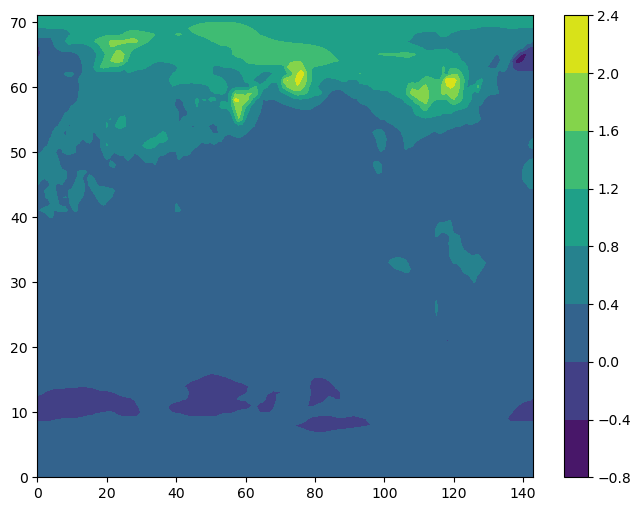

In [359]:
plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(sat_slp[:, -6, 0, :, :, 0], 0))
plt.colorbar()
plt.show()

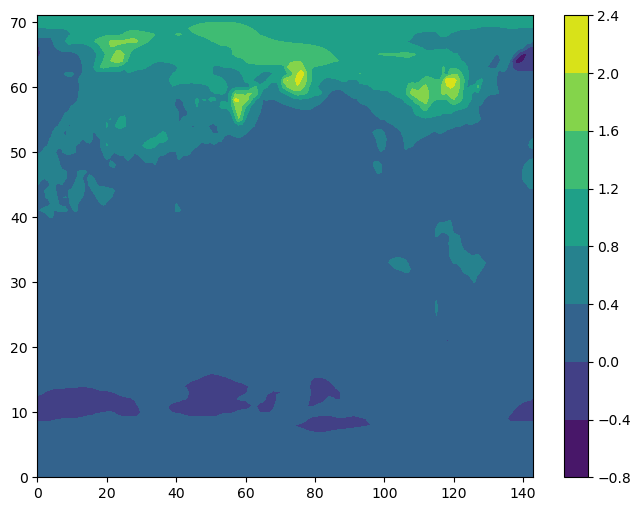

In [360]:
test = xr.open_dataset('/glade/work/skygale/old_training/ssp_processed/global/ACCESS-ESM1-5.nc')
test_sat = test.X_SAT_SLP[:, -6, 0, :, :, 0]
plt.figure(figsize=(8, 6))
plt.contourf(np.nanmean(test_sat, 0))
plt.colorbar()
plt.show()